In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import random
import shutil
import math
import json
import sys
from PIL import Image
from torchvision.transforms import v2

sys.path.append(str(Path("..").resolve()))

from sklearn.preprocessing import LabelEncoder
import tqdm

import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from src.model import CropDiseaseCNN
from src.model import ResNet50Transfer
from src.model import EfficientNetB4Transfer

1. Data preparation:

In [ ]:
# # -----------------------------
# # STORE RESULTS HERE
# # -----------------------------
# results = []

# # -----------------------------
# # PROCESS EACH DATASET
# # -----------------------------
# for dataset_path in SOURCE_DATASETS:

#     print(f"\nProcessing dataset: {dataset_path}")

#     for class_folder in dataset_path.iterdir():

#         if not class_folder.is_dir():
#             continue

#         class_name = class_folder.name

#         image_files = [
#             img for img in class_folder.iterdir()
#             if img.suffix.lower() in IMAGE_EXTENSIONS
#         ]

#         total_images = len(image_files)

#         if total_images == 0:
#             print(f"Skipping empty folder: {class_name}")
#             continue

#         random.shuffle(image_files)

#         train_count = min(500, int(total_images * 0.8))
#         train_images = image_files[:train_count]

#         remaining_images = image_files[train_count:]

#         test_count = min(300, len(remaining_images))
#         test_images = remaining_images[:test_count]

#         train_class_dir = TRAIN_DIR / class_name
#         test_class_dir = TEST_DIR / class_name

#         train_class_dir.mkdir(parents=True, exist_ok=True)
#         test_class_dir.mkdir(parents=True, exist_ok=True)

#         for img_path in train_images:
#             shutil.copy2(img_path, train_class_dir / img_path.name)

#         for img_path in test_images:
#             shutil.copy2(img_path, test_class_dir / img_path.name)

#         # -----------------------------
#         # SAVE ROW
#         # -----------------------------
#         results.append({
#             "dataset": dataset_path.name,
#             "class_name": class_name,
#             "train_count": len(train_images),
#             "test_count": len(test_images),
#             "total_images": total_images
#         })

#         print(
#             f"{class_name} --> "
#             f"Train: {len(train_images)} | "
#             f"Test: {len(test_images)} | "
#             f"Total: {total_images}"
#         )

# # -----------------------------
# # CONVERT TO DATAFRAME
# # -----------------------------
# df_samples_count = pd.DataFrame(results)

# print(df_samples_count.head())


Processing dataset: ..\data\original\plant_dataset_2
Bean_Angular_leaf_spot --> Train: 264 | Test: 66 | Total: 330
Bean_Healthy --> Train: 264 | Test: 66 | Total: 330
Bean_Rust --> Train: 264 | Test: 66 | Total: 330
BlackGram_Anthracnose --> Train: 184 | Test: 46 | Total: 230
BlackGram_Healthy --> Train: 176 | Test: 45 | Total: 221
BlackGram_Leaf Crinckle --> Train: 121 | Test: 31 | Total: 152
BlackGram_Powdery Mildew --> Train: 144 | Test: 36 | Total: 180
BlackGram_Yellow Mosaic --> Train: 179 | Test: 45 | Total: 224
Cotton_Bacterial_Blight --> Train: 200 | Test: 50 | Total: 250
Cotton_Curl_Virus --> Train: 344 | Test: 87 | Total: 431
Cotton_Healthy --> Train: 205 | Test: 52 | Total: 257
Cotton_Herbicide_Growth_Damage --> Train: 224 | Test: 56 | Total: 280
Cotton_Leaf_Hopper_Jassids --> Train: 180 | Test: 45 | Total: 225
Cotton_Leaf_Redding --> Train: 462 | Test: 116 | Total: 578
Cotton_Leaf_Variegation --> Train: 92 | Test: 24 | Total: 116
Cucumber_Downy_mildew --> Train: 500 | Test

In [ ]:
# # ─────────────────────────────────────────────────────────────────────────────
# # BUILD raw_data FROM DATAFRAME
# # ─────────────────────────────────────────────────────────────────────────────
# # Expected dataframe columns:
# # class_name | train_count | test_count | total_images
# # ─────────────────────────────────────────────────────────────────────────────

# raw_data = list(
#     zip(
#         df_samples_count["class_name"],
#         df_samples_count["train_count"],
#         df_samples_count["test_count"],
#         df_samples_count["total_images"]
#     )
# )

# # ─────────────────────────────────────────────────────────────────────────────
# # STEP 1 — Hoeffding's PAC Bound
# # ─────────────────────────────────────────────────────────────────────────────
# # Formula:
# # n >= log(2/delta) / (2 * epsilon²)
# #
# # epsilon → tolerated error
# # delta   → probability of failure
# # confidence = 1 - delta
# # ─────────────────────────────────────────────────────────────────────────────

# def hoeffding_threshold(epsilon: float, delta: float) -> float:
#     """
#     Minimum samples needed so empirical error stays
#     within epsilon of true error with probability >= (1 - delta)
#     """
#     return math.log(2 / delta) / (2 * epsilon ** 2)


# # ─────────────────────────────────────────────────────────────────────────────
# # CONFIGS
# # ─────────────────────────────────────────────────────────────────────────────

# configs = {
#     "Strict   (ε=0.05, δ=0.05) → 95% conf, ±5%  error": (0.05, 0.05),
#     "Balanced (ε=0.10, δ=0.05) → 95% conf, ±10% error": (0.10, 0.05),
#     "Lenient  (ε=0.10, δ=0.10) → 90% conf, ±10% error": (0.10, 0.10),
# }

# print("=" * 70)
# print("  HOEFFDING / PAC-LEARNING THRESHOLD CALCULATION")
# print("=" * 70)

# for label, (eps, dlt) in configs.items():

#     thr = hoeffding_threshold(eps, dlt)

#     print(f"\n  {label}")
#     print(f"  → threshold  = log(2/{dlt}) / (2×{eps}²)")
#     print(f"             = {math.log(2/dlt):.4f} / {2*eps**2:.4f}")
#     print(f"             ≈ {thr:.1f} training samples")


# # ─────────────────────────────────────────────────────────────────────────────
# # STEP 2 — WORKING THRESHOLD
# # ─────────────────────────────────────────────────────────────────────────────

# EPSILON = 0.10
# DELTA = 0.05

# THRESHOLD = hoeffding_threshold(EPSILON, DELTA)

# print("\n" + "=" * 70)
# print(f"  WORKING THRESHOLD  (ε={EPSILON}, δ={DELTA})")
# print(f"  n_min = log(2/{DELTA}) / (2 × {EPSILON}²)")
# print(f"  = {THRESHOLD:.2f}")

# T = math.ceil(THRESHOLD)

# print(f"  → Rounded threshold = {T} training samples")
# print("=" * 70)


# # ─────────────────────────────────────────────────────────────────────────────
# # STEP 3 — CLASSIFY CLASSES
# # ─────────────────────────────────────────────────────────────────────────────

# train_counts = np.array([d[1] for d in raw_data])

# K = len(raw_data)
# N_train = train_counts.sum()

# keep = [
#     (name, tr, te, tot)
#     for name, tr, te, tot in raw_data
#     if tr >= T
# ]

# discard = [
#     (name, tr, te, tot)
#     for name, tr, te, tot in raw_data
#     if tr < T
# ]

# print(f"\n  Total classes       : {K}")
# print(f"  Total train samples : {N_train:,}")
# print(f"  Classes KEPT        : {len(keep)}")
# print(f"  Classes DISCARDED   : {len(discard)}")

# print("\n" + "─" * 70)
# print(f"  {'CLASS':<45} {'TRAIN':>6}  VERDICT")
# print("─" * 70)

# for name, tr, te, tot in sorted(raw_data, key=lambda x: x[1]):

#     status = "✅ KEEP" if tr >= T else "❌ DISCARD"
#     marker = " ◄──" if tr < T else ""

#     print(f"  {name:<45} {tr:>6}  {status}{marker}")


# # ─────────────────────────────────────────────────────────────────────────────
# # STEP 4 — IMPACT ANALYSIS
# # ─────────────────────────────────────────────────────────────────────────────

# kept_train = sum(d[1] for d in keep)
# discarded_train = sum(d[1] for d in discard)

# print("\n" + "=" * 70)
# print("  IMPACT SUMMARY")
# print("=" * 70)

# print(
#     f"  Train samples retained  : "
#     f"{kept_train:,} ({100 * kept_train / N_train:.1f}%)"
# )

# print(
#     f"  Train samples discarded : "
#     f"{discarded_train:,} ({100 * discarded_train / N_train:.1f}%)"
# )


# # ─────────────────────────────────────────────────────────────────────────────
# # STEP 5 — PER-CLASS EPSILON BOUNDS
# # ─────────────────────────────────────────────────────────────────────────────
# # Rearranged Hoeffding:
# #
# # epsilon = sqrt( log(2/delta) / (2*n) )
# # ─────────────────────────────────────────────────────────────────────────────

# print("\n" + "─" * 70)
# print(f"  {'CLASS':<45} {'TRAIN':>6}  {'ε-BOUND':>10}  {'CONF':>6}")
# print("─" * 70)

# for name, tr, te, tot in sorted(raw_data, key=lambda x: x[1]):

#     if tr > 0:
#         eps_i = math.sqrt(math.log(2 / DELTA) / (2 * tr))
#     else:
#         eps_i = float("inf")

#     conf = (1 - DELTA) * 100

#     flag = " ◄── DISCARD" if tr < T else ""

#     print(
#         f"  {name:<45} "
#         f"{tr:>6}  "
#         f"±{eps_i * 100:>6.1f}%   "
#         f"{conf:.0f}%{flag}"
#     )


# # ─────────────────────────────────────────────────────────────────────────────
# # STEP 6 — CREATE RESULT DATAFRAME
# # ─────────────────────────────────────────────────────────────────────────────

# analysis_rows = []

# for name, tr, te, tot in raw_data:

#     eps_i = math.sqrt(math.log(2 / DELTA) / (2 * tr))

#     analysis_rows.append({
#         "class_name": name,
#         "train_count": tr,
#         "test_count": te,
#         "total_images": tot,
#         "epsilon_bound_percent": round(eps_i * 100, 2),
#         "keep_class": tr >= T
#     })

# df_pac_analysis = pd.DataFrame(analysis_rows)

# # Sort by train count
# df_pac_analysis = df_pac_analysis.sort_values(
#     by="train_count"
# ).reset_index(drop=True)

# print("\n")
# print("=" * 70)
# print("PAC ANALYSIS DATAFRAME")
# print("=" * 70)

# display(df_pac_analysis.head())


# # ─────────────────────────────────────────────────────────────────────────────
# # OPTIONAL — SAVE RESULTS
# # ─────────────────────────────────────────────────────────────────────────────

# df_pac_analysis.to_csv(
#     "../data/pac_analysis_results.csv",
#     index=False
# )

# print("\nSaved:")
# print("../data/pac_analysis_results.csv")


# # ─────────────────────────────────────────────────────────────────────────────
# # FINAL INTERPRETATION
# # ─────────────────────────────────────────────────────────────────────────────

# print("\n" + "=" * 70)
# print("  INTERPRETATION")
# print("=" * 70)

# print(f"""
# • Classes with fewer than {T} training samples are discarded.

# • This ensures that empirical training error remains within
#   ±{EPSILON * 100:.0f}% of true generalisation error
#   with {(1 - DELTA) * 100:.0f}% confidence.

# • Lower-sample classes produce very weak statistical guarantees.

# • Retained classes: {len(keep)}
# • Discarded classes: {len(discard)}

# • Total discarded training samples:
#   {discarded_train:,} / {N_train:,}
#   ({100 * discarded_train / N_train:.2f}%)
# """)

  HOEFFDING / PAC-LEARNING THRESHOLD CALCULATION

  Strict   (ε=0.05, δ=0.05) → 95% conf, ±5%  error
  → threshold  = log(2/0.05) / (2×0.05²)
             = 3.6889 / 0.0050
             ≈ 737.8 training samples

  Balanced (ε=0.10, δ=0.05) → 95% conf, ±10% error
  → threshold  = log(2/0.05) / (2×0.1²)
             = 3.6889 / 0.0200
             ≈ 184.4 training samples

  Lenient  (ε=0.10, δ=0.10) → 90% conf, ±10% error
  → threshold  = log(2/0.1) / (2×0.1²)
             = 2.9957 / 0.0200
             ≈ 149.8 training samples

  WORKING THRESHOLD  (ε=0.1, δ=0.05)
  n_min = log(2/0.05) / (2 × 0.1²)
  = 184.44
  → Rounded threshold = 185 training samples

  Total classes       : 108
  Total train samples : 42,548
  Classes KEPT        : 96
  Classes DISCARDED   : 12

──────────────────────────────────────────────────────────────────────
  CLASS                                          TRAIN  VERDICT
──────────────────────────────────────────────────────────────────────
  Onion_Bulb Rot  

,class_name,train_count,test_count,total_images,epsilon_bound_percent,keep_class
0,Onion_Bulb Rot,5,2,7,60.74,False
1,Onion_Downy mildew,29,8,37,25.22,False
2,Cotton_Leaf_Variegation,92,24,116,14.16,False
3,BlackGram_Leaf Crinckle,121,31,152,12.35,False
4,Potato_Healthy,121,31,152,12.35,False



Saved:
../data/pac_analysis_results.csv

  INTERPRETATION

• Classes with fewer than 185 training samples are discarded.

• This ensures that empirical training error remains within
  ±10% of true generalisation error
  with 95% confidence.

• Lower-sample classes produce very weak statistical guarantees.

• Retained classes: 96
• Discarded classes: 12

• Total discarded training samples:
  1,552 / 42,548
  (3.65%)



In [ ]:
# # =========================================================
# # CONFIG
# # =========================================================

# BASE_DIR = Path("../")

# TRAIN_DIR = BASE_DIR / "data/processed/combined_train"
# TEST_DIR = BASE_DIR / "data/processed/combined_test"

# IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp"}

# MIN_SAMPLES = 170

# # =========================================================
# # HELPER FUNCTION
# # =========================================================

# def get_image_count(folder_path):
#     """
#     Count image files inside a folder.
#     """

#     return len([
#         img for img in folder_path.iterdir()
#         if img.suffix.lower() in IMAGE_EXTENSIONS
#     ])


# def get_plant_name(class_name):
#     """
#     Extract plant/fruit/vegetable name.
#     """

#     class_name = class_name.replace(" ", "_")

#     return class_name.split("_")[0]


# # =========================================================
# # CHECK SMALL CLASSES
# # =========================================================

# small_classes = []
# removed_classes = []
# kept_healthy_classes = []

# print("\nChecking class sample counts...\n")

# for train_class_folder in TRAIN_DIR.iterdir():

#     if not train_class_folder.is_dir():
#         continue

#     class_name = train_class_folder.name

#     train_count = get_image_count(train_class_folder)

#     # Corresponding test folder
#     test_class_folder = TEST_DIR / class_name

#     # -----------------------------------------------------
#     # CHECK SMALL CLASSES
#     # -----------------------------------------------------
#     if train_count < MIN_SAMPLES:

#         small_classes.append((class_name, train_count))

# # =========================================================
# # PRINT SMALL CLASSES FIRST
# # =========================================================

# print("=" * 60)
# print(f"CLASSES WITH LESS THAN {MIN_SAMPLES} TRAIN SAMPLES")
# print("=" * 60)

# for class_name, train_count in sorted(small_classes):

#     print(f"{class_name} --> {train_count} samples")

# # =========================================================
# # REMOVE ONLY NON-HEALTHY SMALL CLASSES
# # =========================================================

# print("\n")
# print("=" * 60)
# print("REMOVING NON-HEALTHY SMALL CLASSES")
# print("=" * 60)

# for class_name, train_count in small_classes:

#     train_class_folder = TRAIN_DIR / class_name
#     test_class_folder = TEST_DIR / class_name

#     # -----------------------------------------------------
#     # KEEP HEALTHY CLASSES
#     # -----------------------------------------------------
#     if "healthy" in class_name.lower():

#         print(f"Keeping healthy class: {class_name}")

#         kept_healthy_classes.append(class_name)

#         continue

#     # -----------------------------------------------------
#     # REMOVE NON-HEALTHY SMALL CLASS
#     # -----------------------------------------------------
#     print(f"Removing: {class_name} --> {train_count} samples")

#     shutil.rmtree(train_class_folder, ignore_errors=True)

#     if test_class_folder.exists():
#         shutil.rmtree(test_class_folder, ignore_errors=True)

#     removed_classes.append(class_name)

# print("\nSmall non-healthy classes removed.\n")

# # =========================================================
# # FINAL SUMMARY
# # =========================================================

# plant_summary = {}

# for train_class_folder in TRAIN_DIR.iterdir():

#     if not train_class_folder.is_dir():
#         continue

#     class_name = train_class_folder.name

#     train_count = get_image_count(train_class_folder)

#     test_class_folder = TEST_DIR / class_name

#     test_count = (
#         get_image_count(test_class_folder)
#         if test_class_folder.exists()
#         else 0
#     )

#     plant_name = get_plant_name(class_name)

#     # Create plant entry
#     if plant_name not in plant_summary:
#         plant_summary[plant_name] = []

#     # Store class info
#     plant_summary[plant_name].append({
#         "class_name": class_name,
#         "train_samples": train_count,
#         "test_samples": test_count
#     })

# # =========================================================
# # PRINT FINAL SUMMARY
# # =========================================================

# print("=" * 60)
# print("FINAL DATASET SUMMARY")
# print("=" * 60)

# for plant_name, class_info_list in sorted(plant_summary.items()):

#     print(f"\n{plant_name}")

#     for class_info in sorted(
#         class_info_list,
#         key=lambda x: x["class_name"]
#     ):

#         print(
#             f"   ├── {class_info['class_name']}"
#             f" | Train: {class_info['train_samples']}"
#             f" | Test: {class_info['test_samples']}"
#         )

# # =========================================================
# # FINAL COUNTS
# # =========================================================

# print("\n")
# print("=" * 60)
# print("FINAL REPORT")
# print("=" * 60)

# print(f"Removed classes: {len(removed_classes)}")
# print(f"Kept healthy low-sample classes: {len(kept_healthy_classes)}")

# print("\nCompleted.")


Checking class sample counts...

CLASSES WITH LESS THAN 170 TRAIN SAMPLES
BlackGram_Leaf Crinckle --> 121 samples
BlackGram_Powdery Mildew --> 144 samples
Cotton_Leaf_Variegation --> 92 samples
Onion_Bulb Rot --> 5 samples
Onion_Downy mildew --> 29 samples
Onion_Xanthomonas Leaf Blight --> 151 samples
Potato_Healthy --> 121 samples


REMOVING NON-HEALTHY SMALL CLASSES
Removing: BlackGram_Leaf Crinckle --> 121 samples
Removing: BlackGram_Powdery Mildew --> 144 samples
Removing: Cotton_Leaf_Variegation --> 92 samples
Removing: Onion_Bulb Rot --> 5 samples
Removing: Onion_Downy mildew --> 29 samples
Removing: Onion_Xanthomonas Leaf Blight --> 151 samples
Keeping healthy class: Potato_Healthy

Small non-healthy classes removed.

FINAL DATASET SUMMARY

Apple
   ├── Apple_Apple_Scab | Train: 500 | Test: 130
   ├── Apple_Black_Rot | Train: 496 | Test: 125
   ├── Apple_Cedar_Apple_Rust | Train: 220 | Test: 55
   ├── Apple_Healthy | Train: 500 | Test: 300

Bean
   ├── Bean_Angular_leaf_spot | 

In [ ]:
# # =========================================================
# # CONFIG
# # =========================================================

# # Notebook is inside /notebook
# BASE_DIR = Path("../")

# # Dataset folders
# TRAIN_FOLDER = BASE_DIR / "data/processed/combined_train"
# TEST_FOLDER = BASE_DIR / "data/processed/combined_test"

# # Output CSV files
# TRAIN_CSV_PATH = Path("./train.csv")
# TEST_CSV_PATH = Path("./test.csv")

# # Allowed image extensions
# IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp"}

# # =========================================================
# # HELPER FUNCTION
# # =========================================================

# def format_target_name(folder_name):
#     """
#     Convert folder names into clean labels.

#     Example:
#     Apple Apple Scab -> Apple_Apple_Scab
#     """

#     folder_name = folder_name.replace(" ", "_")

#     while "__" in folder_name:
#         folder_name = folder_name.replace("__", "_")

#     return folder_name.strip("_")


# def process_dataset(dataset_folder):
#     """
#     Rename images and create dataframe records.
#     """

#     dataset_records = []

#     print(f"\nProcessing: {dataset_folder}")

#     # Iterate through class folders
#     for class_folder in dataset_folder.iterdir():

#         if not class_folder.is_dir():
#             continue

#         # ---------------------------------------------
#         # TARGET LABEL
#         # ---------------------------------------------
#         target_label = format_target_name(class_folder.name)

#         # ---------------------------------------------
#         # IMAGE FILES
#         # ---------------------------------------------
#         image_files = sorted([
#             img for img in class_folder.iterdir()
#             if img.suffix.lower() in IMAGE_EXTENSIONS
#         ])

#         print(f"{class_folder.name} --> {len(image_files)} images")

#         # ---------------------------------------------
#         # RENAME IMAGES
#         # ---------------------------------------------
#         for idx, image_path in enumerate(image_files, start=1):

#             extension = image_path.suffix.lower()

#             # Example:
#             # Apple_Apple_Scab_0001.png
#             new_name = f"{target_label}_{idx:04d}{extension}"

#             new_path = class_folder / new_name

#             # Rename only if needed
#             if image_path.name != new_name:

#                 try:
#                     shutil.move(str(image_path), str(new_path))

#                 except PermissionError:
#                     print(f"Skipped locked file: {image_path.name}")
#                     continue

#             # Relative path from project root
#             relative_path = new_path.relative_to(BASE_DIR)

#             # Store record
#             dataset_records.append({
#                 "image_name": new_name,
#                 "image_path": str(relative_path),
#                 "target": target_label
#             })

#     return pd.DataFrame(dataset_records)


# # =========================================================
# # PROCESS TRAIN DATASET
# # =========================================================

# train_df = process_dataset(TRAIN_FOLDER)

# # Save train CSV
# train_df.to_csv(TRAIN_CSV_PATH, index=False)

# print("\nTrain CSV saved:")
# print(TRAIN_CSV_PATH.resolve())

# print(f"Total train samples: {len(train_df)}")


# # =========================================================
# # PROCESS TEST DATASET
# # =========================================================

# test_df = process_dataset(TEST_FOLDER)

# # Save test CSV
# test_df.to_csv(TEST_CSV_PATH, index=False)

# print("\nTest CSV saved:")
# print(TEST_CSV_PATH.resolve())

# print(f"Total test samples: {len(test_df)}")


# # =========================================================
# # PREVIEW
# # =========================================================

# print("\nTrain Data Preview:")
# display(train_df.head())

# print("\nTest Data Preview:")
# display(test_df.head())


Processing: ..\data\processed\combined_train
Apple_Apple_Scab --> 500 images
Apple_Black_Rot --> 496 images
Apple_Cedar_Apple_Rust --> 220 images
Apple_Healthy --> 500 images
Bean_Angular_leaf_spot --> 264 images
Bean_Healthy --> 264 images
Bean_Rust --> 264 images
BlackGram_Anthracnose --> 184 images
BlackGram_Healthy --> 176 images
BlackGram_Yellow Mosaic --> 179 images
Cherry_Healthy --> 500 images
Cherry_Powdery_Mildew --> 500 images
Corn_Cercospora_Leaf_Spot Gray_Leaf_Spot --> 410 images
Corn_Common_Rust --> 500 images
Corn_Healthy --> 500 images
Corn_Northern_Leaf_Blight --> 500 images
Cotton_Bacterial_Blight --> 200 images
Cotton_Curl_Virus --> 344 images
Cotton_Healthy --> 205 images
Cotton_Herbicide_Growth_Damage --> 224 images
Cotton_Leaf_Hopper_Jassids --> 180 images
Cotton_Leaf_Redding --> 462 images
Cucumber_Downy_mildew --> 500 images
Cucumber_Healthy_leaves --> 500 images
Cucumber_Powdery_mildew --> 500 images
Grape_Black_Rot --> 500 images
Grape_Esca_Black_Measles) -->

,image_name,image_path,target
0,Apple_Apple_Scab_0001.jpg,data\processed\combined_train\Apple_Apple_Scab...,Apple_Apple_Scab
1,Apple_Apple_Scab_0002.jpg,data\processed\combined_train\Apple_Apple_Scab...,Apple_Apple_Scab
2,Apple_Apple_Scab_0003.jpg,data\processed\combined_train\Apple_Apple_Scab...,Apple_Apple_Scab
3,Apple_Apple_Scab_0004.jpg,data\processed\combined_train\Apple_Apple_Scab...,Apple_Apple_Scab
4,Apple_Apple_Scab_0005.jpg,data\processed\combined_train\Apple_Apple_Scab...,Apple_Apple_Scab



Test Data Preview:


,image_name,image_path,target
0,Apple_Apple_Scab_0001.jpg,data\processed\combined_test\Apple_Apple_Scab\...,Apple_Apple_Scab
1,Apple_Apple_Scab_0002.jpg,data\processed\combined_test\Apple_Apple_Scab\...,Apple_Apple_Scab
2,Apple_Apple_Scab_0003.jpg,data\processed\combined_test\Apple_Apple_Scab\...,Apple_Apple_Scab
3,Apple_Apple_Scab_0004.jpg,data\processed\combined_test\Apple_Apple_Scab\...,Apple_Apple_Scab
4,Apple_Apple_Scab_0005.jpg,data\processed\combined_test\Apple_Apple_Scab\...,Apple_Apple_Scab


2. Visualizing the number of samples for healthy and diseased fruits and vegetable plants:

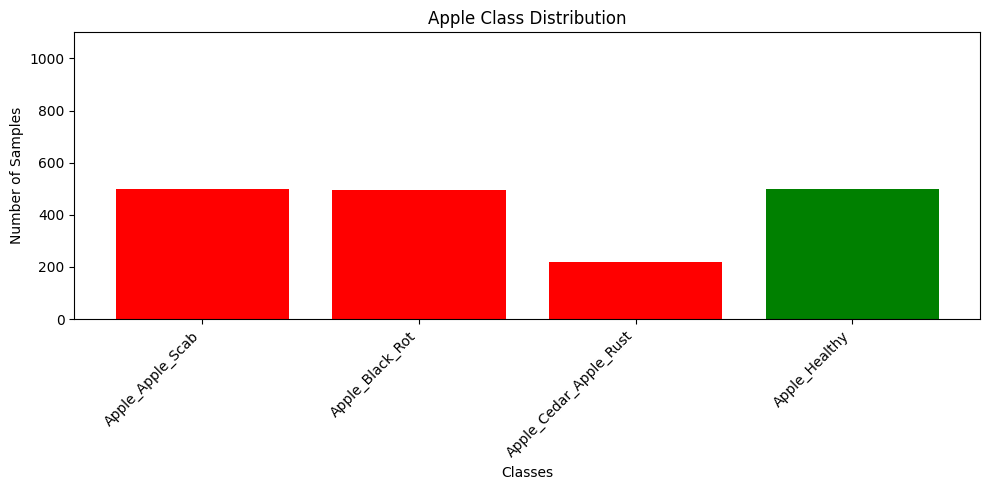

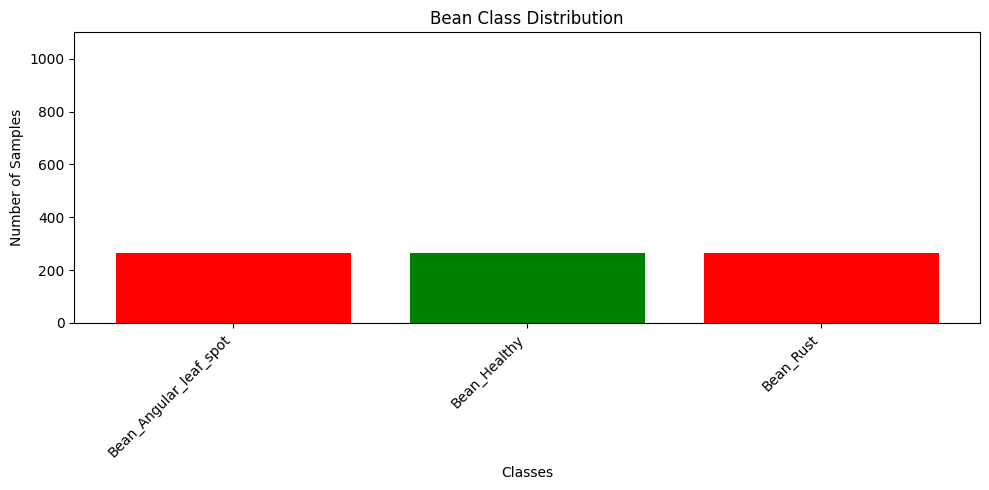

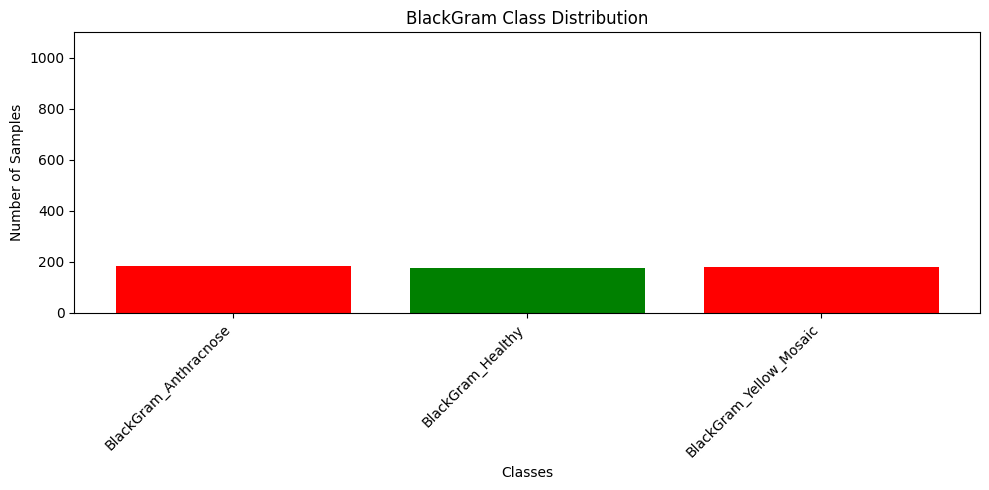

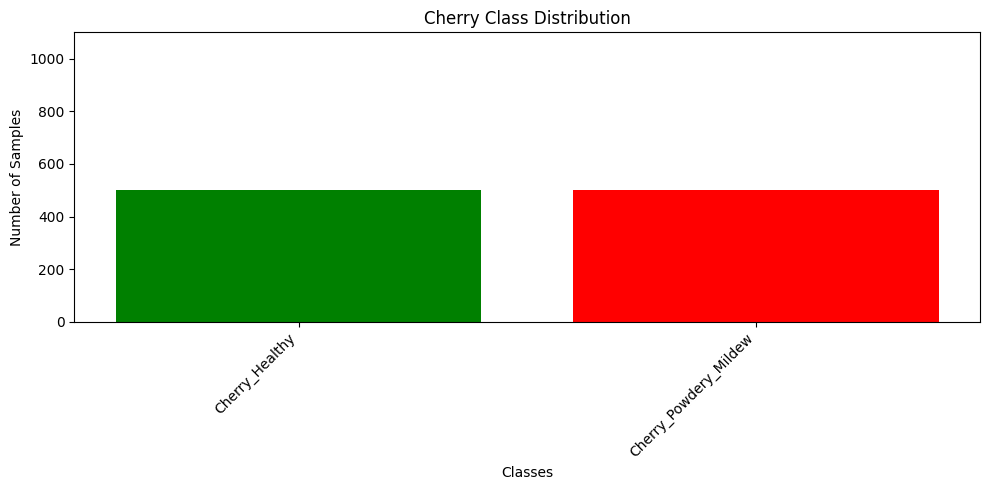

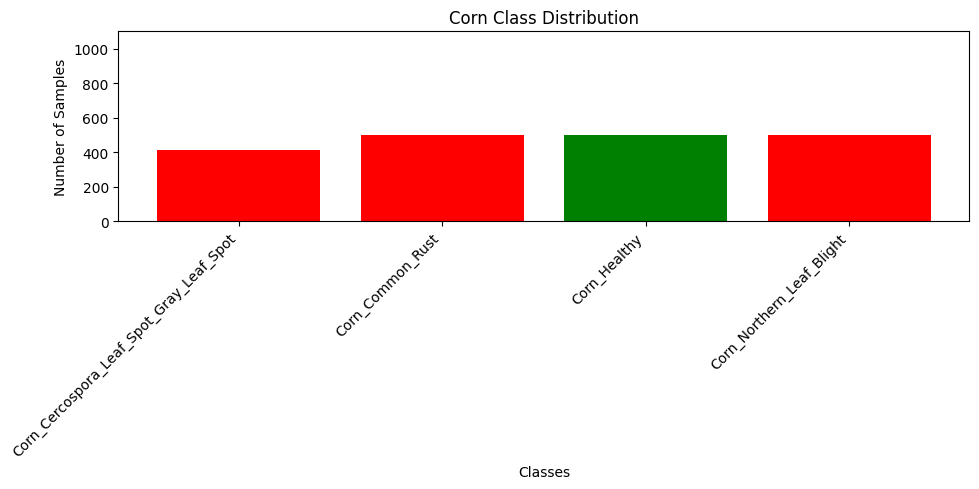

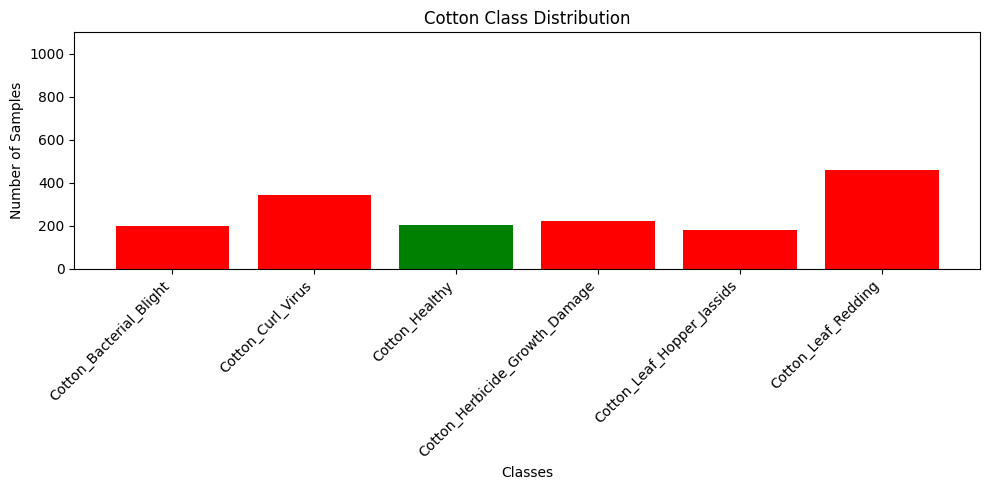

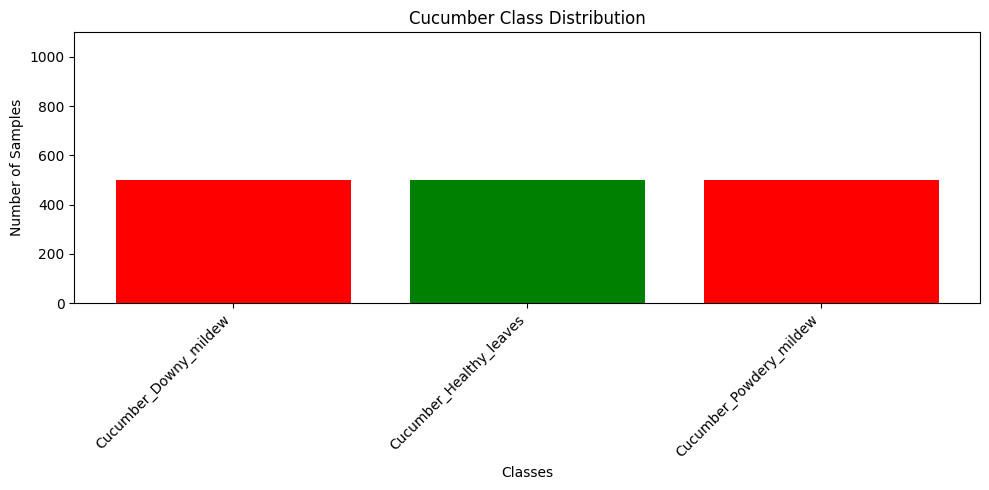

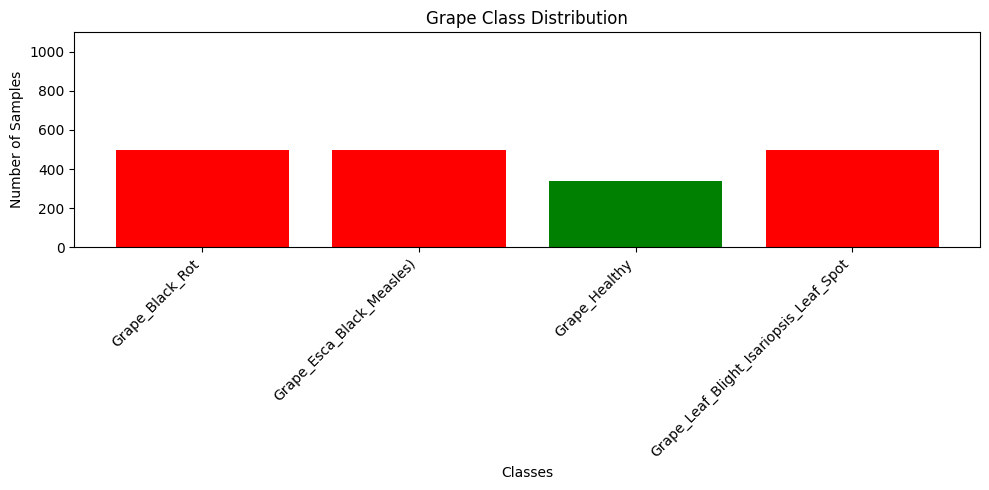

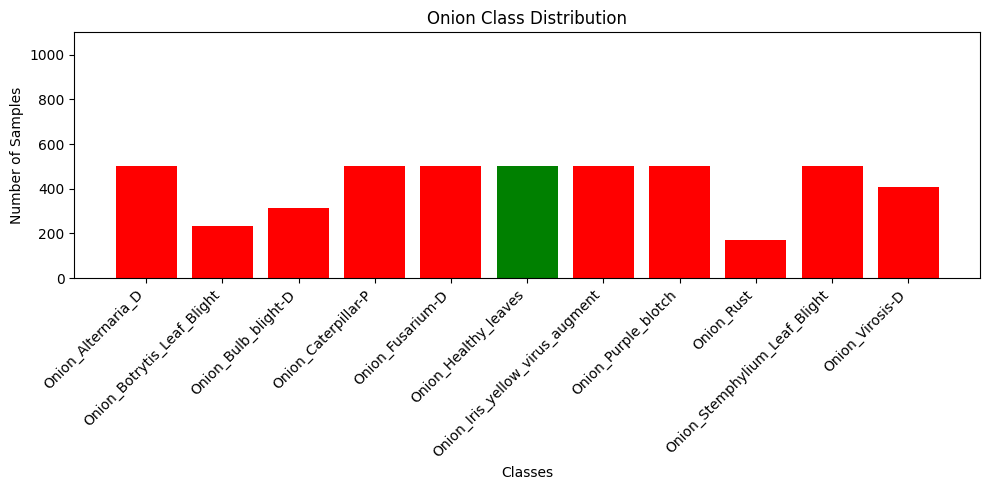

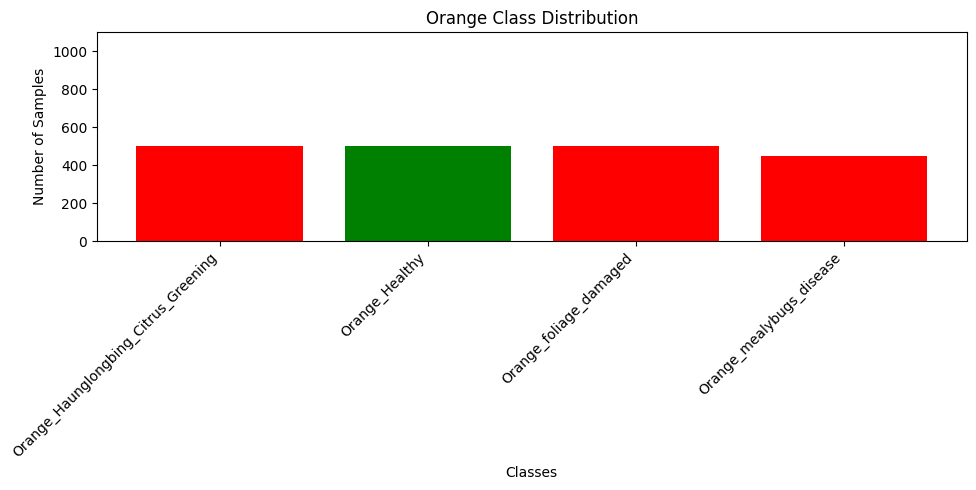

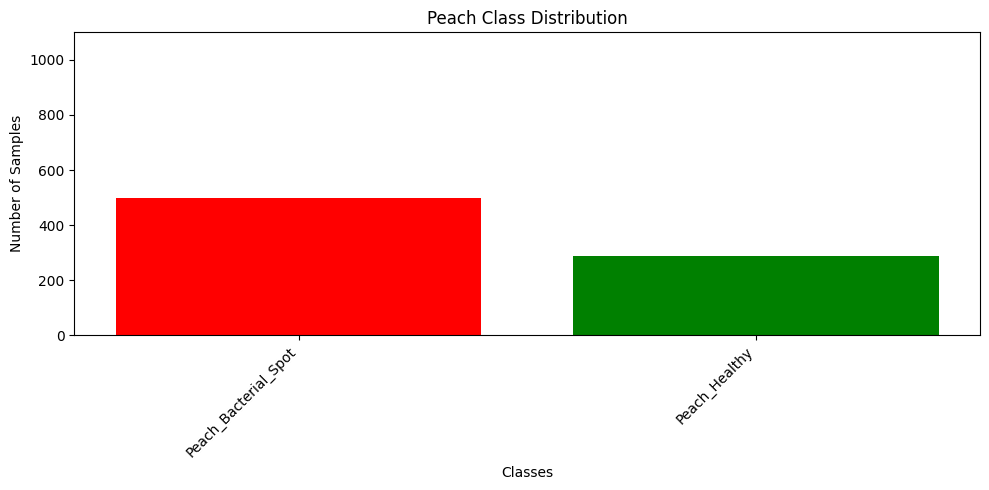

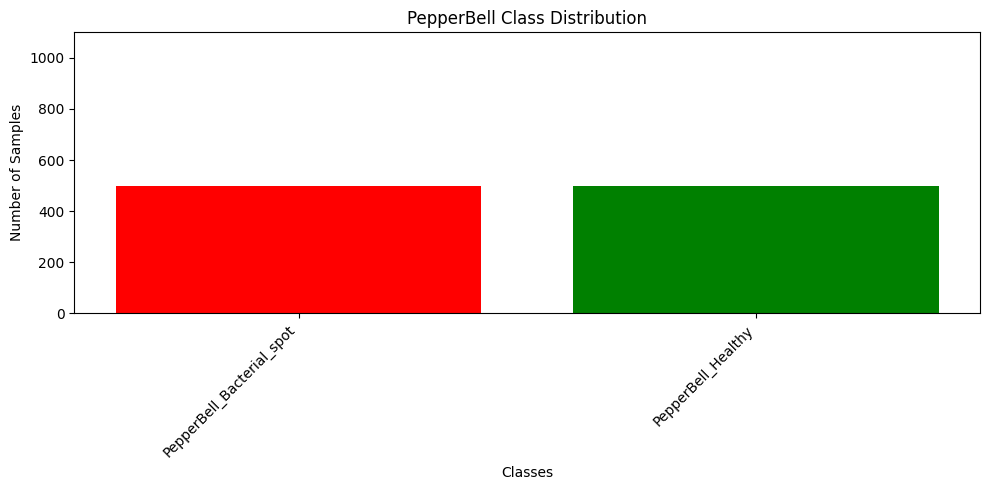

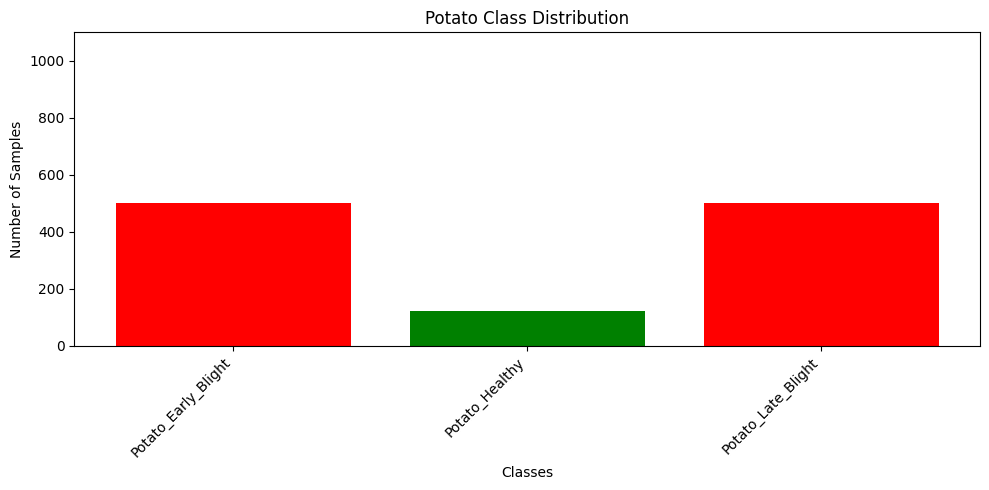

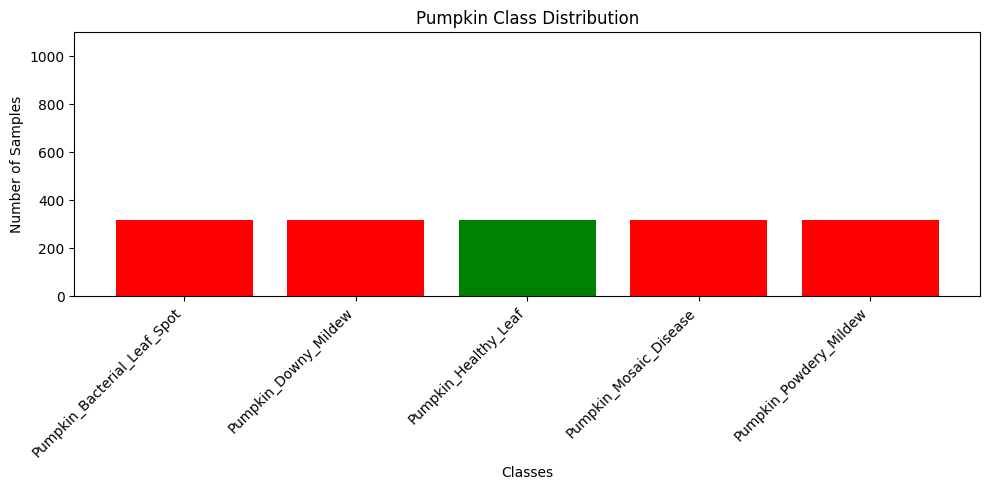

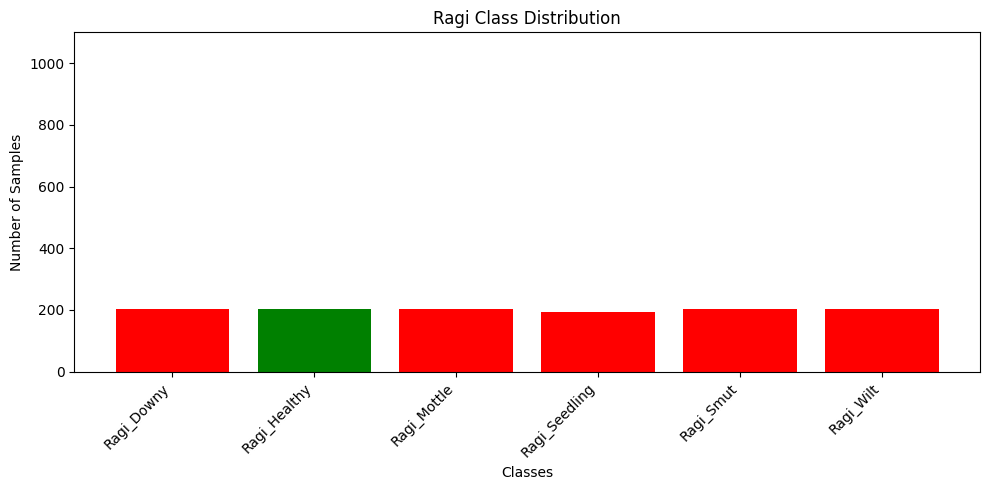

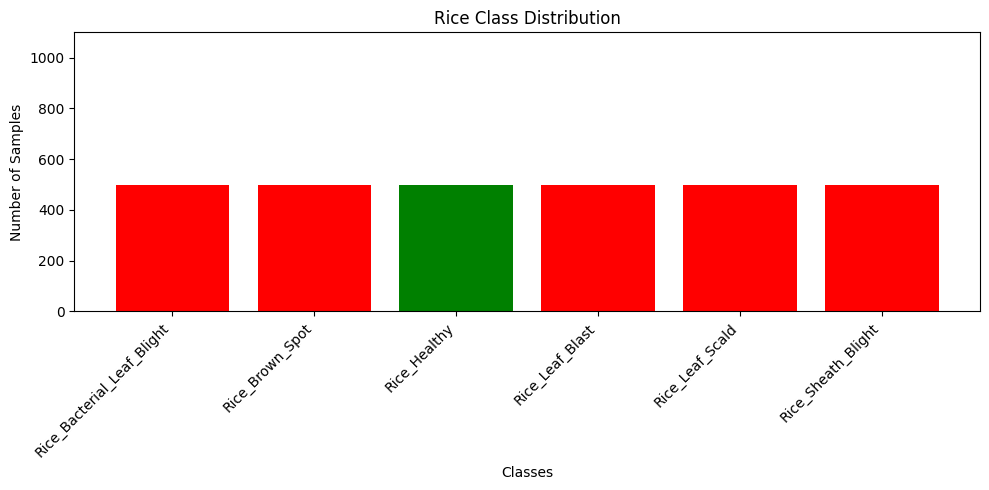

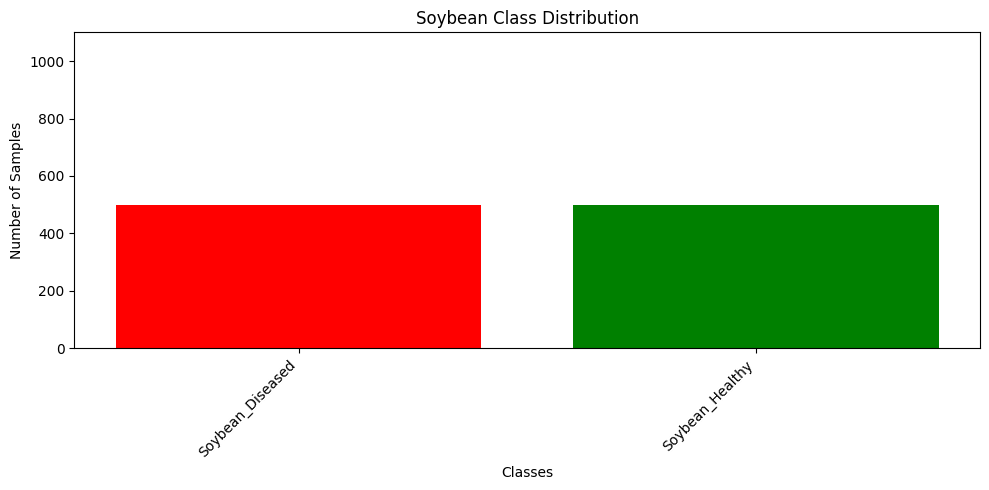

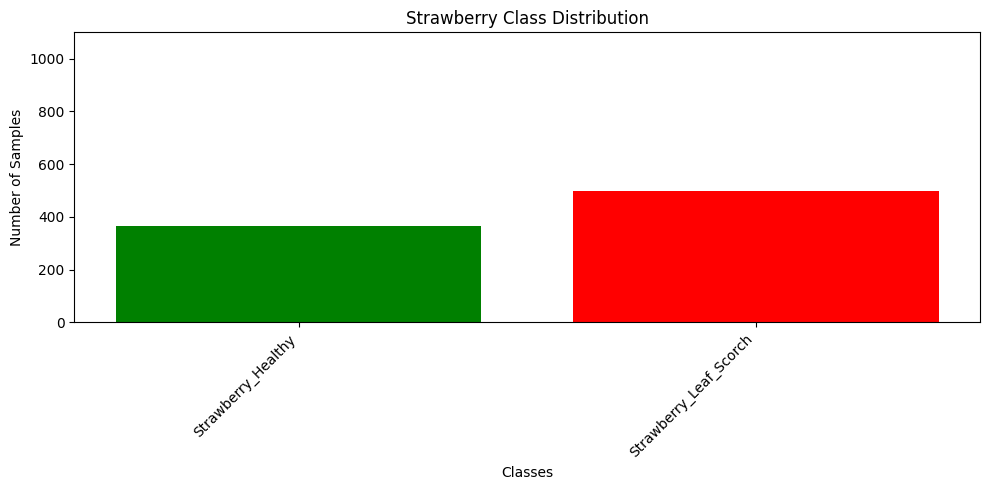

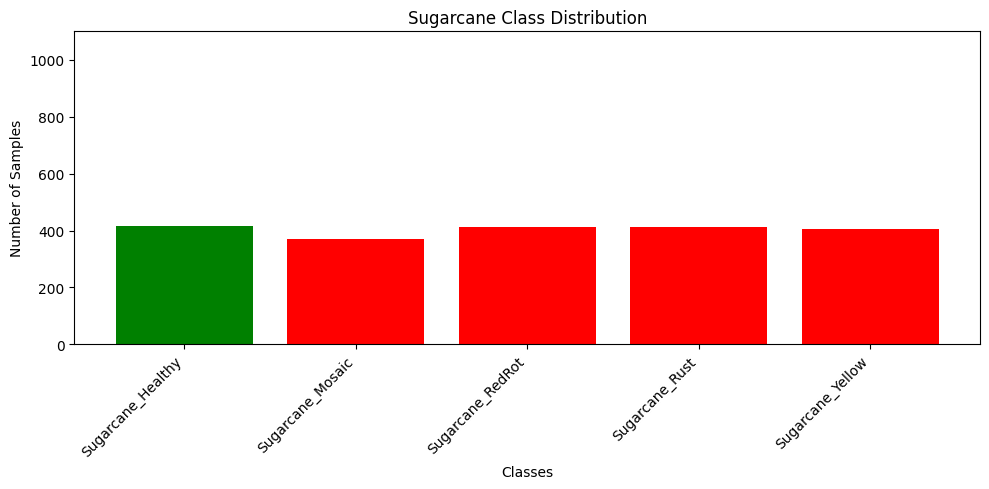

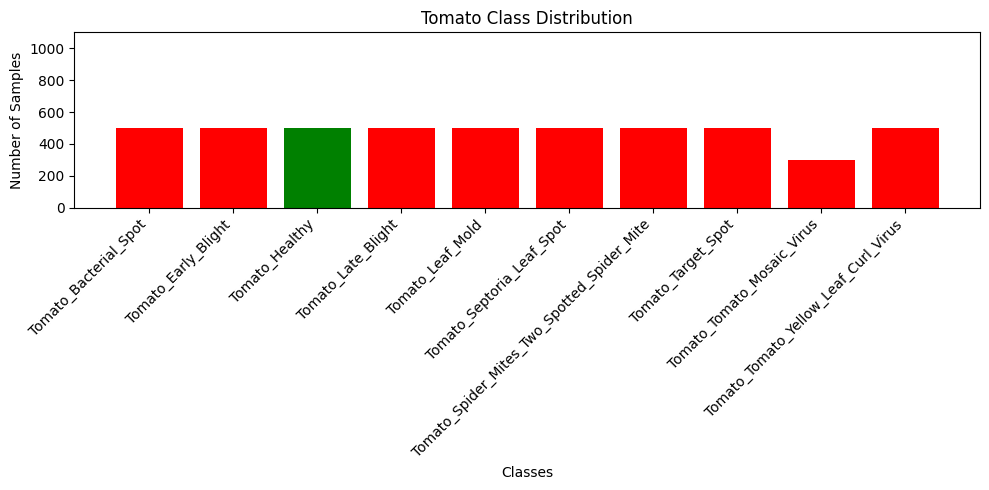

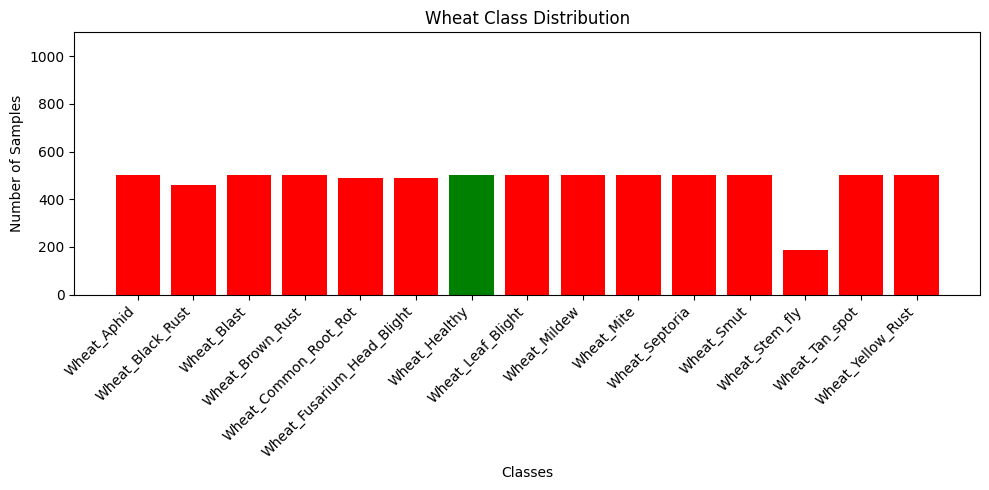

In [ ]:
# # =========================================================
# # LOAD CSV
# # =========================================================

# train_df = pd.read_csv("train.csv")

# # =========================================================
# # EXTRACT MAIN PLANT NAME
# # =========================================================
# # Example:
# # Apple_Apple_Scab  -> Apple
# # Tomato_Healthy    -> Tomato

# train_df["plant"] = train_df["target"].apply(
#     lambda x: x.split("_")[0]
# )

# # =========================================================
# # COUNT SAMPLES
# # =========================================================

# class_counts = (
#     train_df
#     .groupby(["plant", "target"])
#     .size()
#     .reset_index(name="count")
# )

# # =========================================================
# # PLOT
# # =========================================================

# plants = class_counts["plant"].unique()

# for plant in plants:

#     plant_df = class_counts[class_counts["plant"] == plant]

#     plt.figure(figsize=(10, 5))

#     # Colors:
#     # Healthy -> green
#     # Disease -> red
#     colors = [
#         "green" if "healthy" in cls.lower() else "red"
#         for cls in plant_df["target"]
#     ]

#     plt.bar(
#         plant_df["target"],
#         plant_df["count"],
#         color=colors
#     )

#     # Max limit
#     plt.ylim(0, 1100)

#     plt.title(f"{plant} Class Distribution")
#     plt.xlabel("Classes")
#     plt.ylabel("Number of Samples")

#     plt.xticks(rotation=45, ha="right")

#     plt.tight_layout()

#     plt.show()

3. Label Encoding:

In this section we label encode the target variables.

In [ ]:
# # ---------------------------------------------------------
# # LOAD CSVs
# # ---------------------------------------------------------
# train_df = pd.read_csv("./train.csv")
# test_df = pd.read_csv("./test.csv")

# print(f"Train samples loaded: {len(train_df)}")
# print(f"Test  samples loaded: {len(test_df)}")

# # ---------------------------------------------------------
# # FIT LABEL ENCODER ON TRAINING TARGETS
# # ---------------------------------------------------------
# label_encoder = LabelEncoder()
# label_encoder.fit(train_df["target"])

# # ---------------------------------------------------------
# # TRANSFORM BOTH TRAIN AND TEST
# # ---------------------------------------------------------
# train_df["label"] = label_encoder.transform(train_df["target"])
# test_df["label"] = label_encoder.transform(test_df["target"])

# # ---------------------------------------------------------
# # BUILD CLASS MAPPING
# # ---------------------------------------------------------
# class_names = label_encoder.classes_.tolist()
# num_classes = len(class_names)

# label_to_class = {idx: name for idx, name in enumerate(class_names)}
# class_to_label = {name: idx for idx, name in enumerate(class_names)}

# # ---------------------------------------------------------
# # SAVE MAPPING TO JSON (in configs/ folder)
# # ---------------------------------------------------------
# configs_dir = Path("../configs")
# configs_dir.mkdir(parents=True, exist_ok=True)

# mapping_path = configs_dir / "label_mapping.json"

# mapping_data = {
#     "num_classes": num_classes,
#     "label_to_class": {str(k): v for k, v in label_to_class.items()},
#     "class_to_label": class_to_label,
# }

# with open(mapping_path, "w") as f:
#     json.dump(mapping_data, f, indent=4)

# print(f"\nLabel mapping saved: {mapping_path.resolve()}")
# print(f"Number of classes:   {num_classes}")

# # ---------------------------------------------------------
# # SAVE UPDATED CSVs
# # ---------------------------------------------------------
# train_df.to_csv("./train.csv", index=False)
# test_df.to_csv("./test.csv", index=False)

# print(f"\nUpdated train.csv ({len(train_df)} rows)")
# print(f"Updated test.csv  ({len(test_df)} rows)")

# # ---------------------------------------------------------
# # PREVIEW
# # ---------------------------------------------------------
# print("\n" + "=" * 60)
# print("  LABEL ENCODING COMPLETE")
# print("=" * 60)

# print("\nTrain preview:")
# display(train_df[["image_name", "target", "label"]].head())

# print("\nTest preview:")
# display(test_df[["image_name", "target", "label"]].head())

# print("\nClass mapping (first 10):")
# for idx in range(min(10, num_classes)):
#     print(f"  {idx:>3} -> {class_names[idx]}")
# if num_classes > 10:
#     print(f"  ... ({num_classes - 10} more classes)")


Train samples loaded: 42006
Test  samples loaded: 19167

Label mapping saved: C:\Users\sandi\Desktop\ML Working Folder\crop_disease_detection\configs\label_mapping.json
Number of classes:   102

Updated train.csv (42006 rows)
Updated test.csv  (19167 rows)

  LABEL ENCODING COMPLETE

Train preview:


,image_name,target,label
0,Apple_Apple_Scab_0001.jpg,Apple_Apple_Scab,0
1,Apple_Apple_Scab_0002.jpg,Apple_Apple_Scab,0
2,Apple_Apple_Scab_0003.jpg,Apple_Apple_Scab,0
3,Apple_Apple_Scab_0004.jpg,Apple_Apple_Scab,0
4,Apple_Apple_Scab_0005.jpg,Apple_Apple_Scab,0



Test preview:


,image_name,target,label
0,Apple_Apple_Scab_0001.jpg,Apple_Apple_Scab,0
1,Apple_Apple_Scab_0002.jpg,Apple_Apple_Scab,0
2,Apple_Apple_Scab_0003.jpg,Apple_Apple_Scab,0
3,Apple_Apple_Scab_0004.jpg,Apple_Apple_Scab,0
4,Apple_Apple_Scab_0005.jpg,Apple_Apple_Scab,0



Class mapping (first 10):
    0 -> Apple_Apple_Scab
    1 -> Apple_Black_Rot
    2 -> Apple_Cedar_Apple_Rust
    3 -> Apple_Healthy
    4 -> Bean_Angular_leaf_spot
    5 -> Bean_Healthy
    6 -> Bean_Rust
    7 -> BlackGram_Anthracnose
    8 -> BlackGram_Healthy
    9 -> BlackGram_Yellow_Mosaic
  ... (92 more classes)


In [3]:
# Load model
model = CropDiseaseCNN(num_classes=102)
checkpoint = torch.load("../results/cnn_baseline/models/best_model_fold_1.pth", map_location="cpu", weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

# See what's inside the checkpoint
print(checkpoint.keys())  # ['model_state_dict', 'optimizer_state_dict', 'val_metrics', 'config', 'epoch', 'fold']
print(f"Trained for {checkpoint['epoch']} epochs")
print(f"Accuracy:           {checkpoint['val_metrics']['accuracy']:.4f}")
print(f"Precision (macro):  {checkpoint['val_metrics']['precision_macro']:.4f}")
print(f"Recall (macro):     {checkpoint['val_metrics']['recall_macro']:.4f}")
print(f"F1 (macro):         {checkpoint['val_metrics']['f1_macro']:.4f}")

dict_keys(['fold', 'epoch', 'model_state_dict', 'optimizer_state_dict', 'val_metrics', 'config'])
Trained for 101 epochs
Accuracy:           0.8431
Precision (macro):  0.8190
Recall (macro):     0.8667
F1 (macro):         0.8309


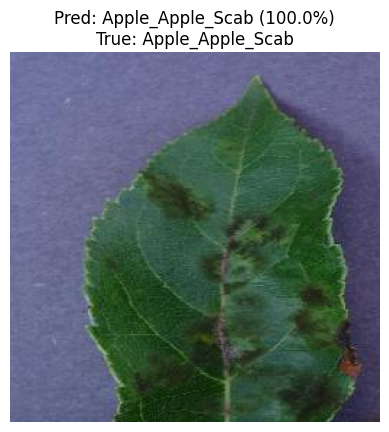

✅ Correct!


In [5]:
# --- Load label mapping ---
with open("../configs/label_mapping.json") as f:
    label_map = json.load(f)
idx_to_class = label_map["label_to_class"]  # {"0": "Apple_Apple_Scab", ...}

# --- Preprocessing (same as eval transforms) ---
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

def preprocess_image(img_path):
    img = Image.open(img_path).convert("RGB")
    img = img.resize((256, 256))
    img_tensor = torch.from_numpy(np.array(img)).permute(2, 0, 1).float() / 255.0
    # CenterCrop to 224
    img_tensor = v2.functional.center_crop(img_tensor, [224, 224])
    # Normalize
    img_tensor = v2.functional.normalize(img_tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD)
    return img_tensor.unsqueeze(0)  # add batch dim

# --- Predict ---
img_path = r"..\data\original\plantvillage dataset\Apple_Apple_Scab\ff99efdc-a9f8-4360-9c64-f8274f456be5___FREC_Scab 3161.JPG"  # <-- change this to any image
true_label = "Apple_Apple_Scab"  # <-- the actual label

input_tensor = preprocess_image(img_path)
with torch.no_grad():
    logits = model(input_tensor)
    pred_idx = logits.argmax(dim=1).item()
    confidence = torch.softmax(logits, dim=1)[0, pred_idx].item()

pred_class = idx_to_class[str(pred_idx)]

# --- Display ---
img = Image.open(img_path)
plt.imshow(img)
plt.title(f"Pred: {pred_class} ({confidence:.1%})\nTrue: {true_label}", fontsize=12)
plt.axis("off")
plt.show()

print(f"✅ Correct!" if pred_class == true_label else f"❌ Wrong! Predicted: {pred_class}")

In [ ]:
model = ResNet50Transfer(num_classes=102)
checkpoint = torch.load("../results/resnet_50/models/best_model_fold_1.pth", map_location="cpu", weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

# See what's inside the checkpoint
print(checkpoint.keys())  # ['model_state_dict', 'optimizer_state_dict', 'val_metrics', 'config', 'epoch', 'fold']
print(f"Trained for {checkpoint['epoch']} epochs")
print(f"Accuracy:           {checkpoint['val_metrics']['accuracy']:.4f}")
print(f"Precision (macro):  {checkpoint['val_metrics']['precision_macro']:.4f}")
print(f"Recall (macro):     {checkpoint['val_metrics']['recall_macro']:.4f}")
print(f"F1 (macro):         {checkpoint['val_metrics']['f1_macro']:.4f}")

dict_keys(['fold', 'epoch', 'model_state_dict', 'optimizer_state_dict', 'val_metrics', 'config'])
Trained for 18 epochs
Accuracy:           0.9372
Precision (macro):  0.9322
Recall (macro):     0.9440
F1 (macro):         0.9360


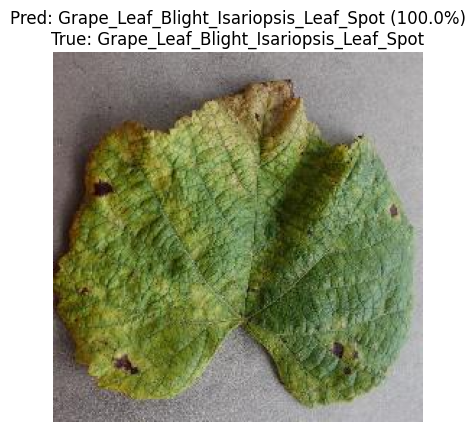

Loaded ResNet-50 from epoch 18
Val F1 macro: 0.9360
✅ Correct!


In [9]:

# Load ResNet-50 model
resnet_model = get_model("resnet_50", num_classes=102)
checkpoint = torch.load("../results/resnet_50/models/best_model_fold_1.pth", map_location="cpu", weights_only=False)
resnet_model.load_state_dict(checkpoint["model_state_dict"])
resnet_model.eval()

# --- Load label mapping ---
with open("../configs/label_mapping.json") as f:
    label_map = json.load(f)
idx_to_class = label_map["label_to_class"]

# --- Preprocessing (same as eval transforms) ---
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

def preprocess_image(img_path):
    img = Image.open(img_path).convert("RGB")
    img = img.resize((256, 256))
    img_tensor = torch.from_numpy(np.array(img)).permute(2, 0, 1).float() / 255.0
    # CenterCrop to 224
    img_tensor = v2.functional.center_crop(img_tensor, [224, 224])
    # Normalize
    img_tensor = v2.functional.normalize(img_tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD)
    return img_tensor.unsqueeze(0)  # add batch dim

# --- Predict ---
img_path = r"..\data\original\plantvillage dataset\Grape_Leaf_Blight_Isariopsis_Leaf_Spot\fe221399-b4f0-419e-95e9-151ae24c81a1___FAM_L.Blight 4595.JPG" # <-- change this to any image
true_label = "Grape_Leaf_Blight_Isariopsis_Leaf_Spot"  # <-- the actual label

input_tensor = preprocess_image(img_path)
with torch.no_grad():
    logits = resnet_model(input_tensor)
    pred_idx = logits.argmax(dim=1).item()
    confidence = torch.softmax(logits, dim=1)[0, pred_idx].item()

pred_class = idx_to_class[str(pred_idx)]

# --- Display ---
img = Image.open(img_path)
plt.imshow(img)
plt.title(f"Pred: {pred_class} ({confidence:.1%})\nTrue: {true_label}", fontsize=12)
plt.axis("off")
plt.show()

print(f"Loaded ResNet-50 from epoch {checkpoint['epoch']}")
print(f"Val F1 macro: {checkpoint['val_metrics']['f1_macro']:.4f}")

print(f"✅ Correct!" if pred_class == true_label else f"❌ Wrong! Predicted: {pred_class}")

In [15]:
model = EfficientNetB4Transfer(num_classes=102)
checkpoint = torch.load("../results/efficientnet_b4/models/best_model_fold_1.pth", map_location="cpu", weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

# See what's inside the checkpoint
print(checkpoint.keys())  # ['model_state_dict', 'optimizer_state_dict', 'val_metrics', 'config', 'epoch', 'fold']
print(f"Trained for {checkpoint['epoch']} epochs")
print(f"Accuracy:           {checkpoint['val_metrics']['accuracy']:.4f}")
print(f"Precision (macro):  {checkpoint['val_metrics']['precision_macro']:.4f}")
print(f"Recall (macro):     {checkpoint['val_metrics']['recall_macro']:.4f}")
print(f"F1 (macro):         {checkpoint['val_metrics']['f1_macro']:.4f}")

Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to C:\Users\sandi/.cache\torch\hub\checkpoints\efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:17<00:00, 4.57MB/s]


dict_keys(['fold', 'epoch', 'model_state_dict', 'optimizer_state_dict', 'val_metrics', 'config'])
Trained for 22 epochs
Accuracy:           0.8993
Precision (macro):  0.8869
Recall (macro):     0.9114
F1 (macro):         0.8942


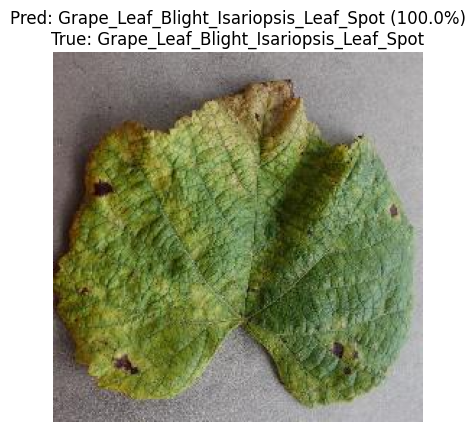

Loaded ResNet-50 from epoch 22
Val F1 macro: 0.8942
✅ Correct!


In [18]:
efficientnet_b4 = get_model("efficientnet_b4", num_classes=102)
# Line 2: load EfficientNet checkpoint, not ResNet
checkpoint = torch.load("../results/efficientnet_b4/models/best_model_fold_1.pth", map_location="cpu", weights_only=False)
efficientnet_b4.load_state_dict(checkpoint["model_state_dict"])
efficientnet_b4.eval()

# --- Load label mapping ---
with open("../configs/label_mapping.json") as f:
    label_map = json.load(f)
idx_to_class = label_map["label_to_class"]

# --- Preprocessing (same as eval transforms) ---
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

def preprocess_image(img_path):
    img = Image.open(img_path).convert("RGB")
    img = img.resize((256, 256))
    img_tensor = torch.from_numpy(np.array(img)).permute(2, 0, 1).float() / 255.0
    # CenterCrop to 224
    img_tensor = v2.functional.center_crop(img_tensor, [224, 224])
    # Normalize
    img_tensor = v2.functional.normalize(img_tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD)
    return img_tensor.unsqueeze(0)  # add batch dim

# --- Predict ---
img_path = r"..\data\original\plantvillage dataset\Grape_Leaf_Blight_Isariopsis_Leaf_Spot\fe221399-b4f0-419e-95e9-151ae24c81a1___FAM_L.Blight 4595.JPG" # <-- change this to any image
true_label = "Grape_Leaf_Blight_Isariopsis_Leaf_Spot"  # <-- the actual label

input_tensor = preprocess_image(img_path)
with torch.no_grad():
    logits = efficientnet_b4(input_tensor)
    pred_idx = logits.argmax(dim=1).item()
    confidence = torch.softmax(logits, dim=1)[0, pred_idx].item()

pred_class = idx_to_class[str(pred_idx)]

# --- Display ---
img = Image.open(img_path)
plt.imshow(img)
plt.title(f"Pred: {pred_class} ({confidence:.1%})\nTrue: {true_label}", fontsize=12)
plt.axis("off")
plt.show()

print(f"Loaded ResNet-50 from epoch {checkpoint['epoch']}")
print(f"Val F1 macro: {checkpoint['val_metrics']['f1_macro']:.4f}")

print(f"✅ Correct!" if pred_class == true_label else f"❌ Wrong! Predicted: {pred_class}")